# Step 2. Merge CTD (1 s) and SUNA data

Implements the merge described on slide 7 of the OMI CTD Data Processing deck (June 2026).

**Goal:** interpolate the SUNA `.csv` data onto the CTD `*_1s.cnv` time base to produce a
combined `*_SUNA_1s.csv` with CTD + SUNA columns at 1 s resolution.

```text
Inputs
  SUNA .csv         <- L1/SUNA
  CTD  *_1s.cnv     <- L2/CTD/CTD_1s   (Bin Average 1 s full cast, from step01)
Output
  *_SUNA_1s.csv     -> L2/SUNA
```

## Why time, not depth, is the merge key

The CTD and SUNA are separate instruments on the same rosette, each on its own clock. The robust
common axis is **UTC time**, not pressure: two scans can share a depth on down- and up-cast but be
seconds apart. We build an absolute UTC timestamp for each instrument and interpolate SUNA nitrate
onto the CTD 1 s timestamps.

Two clock issues are handled explicitly:

* **SUNA internal clock drift.** Zheng et al. (2024) report the SUNA internal clock can drift
  1–2 s over 24–48 h, and accurate time alignment matters because the CTD T/S/P is what converts
  SUNA absorbance to nitrate. A configurable `SUNA_CLOCK_OFFSET_S` is applied.
* **A maximum match gap.** SUNA samples farther than `MAX_MATCH_GAP_S` from any CTD 1 s scan are
  left NaN rather than interpolated across a gap.

## Optional salinity despiking (decisions-memo option b)

If despiking was deferred from the CTD chain (Wild Edit / Filter gated off in step01), this
notebook can apply a light salinity-spike removal on the 1 s salinity **before** it is written into
the merged product, so the downstream nitrate QC (step03 / L3) is not fed spikes
(Ferrari & Rudnick 2000; Zheng et al. 2024). Controlled by `APPLY_SALINITY_DESPIKE`. This is a
pragmatic median/MAD spike filter, **not** the full thermistor-lag reconstruction; the proper fix is
to re-enable Wild Edit in step01. Off by default.


## 1. Imports and settings

In [1]:
from __future__ import annotations

import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)


In [2]:
# ===========================================================================
# Paths  (must match step01 v2 layout)
# ===========================================================================
CTD_ROOT     = Path(r"C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd")
CRUISES_ROOT = CTD_ROOT / "cruises"

CRUISE_ID  = "P45_06"
CRUISE_DIR = CRUISES_ROOT / CRUISE_ID

L1_SUNA_ROOT = CRUISE_DIR / "L1" / "SUNA"             # SUNA .csv input
L2_1S_ROOT   = CRUISE_DIR / "L2" / "CTD" / "CTD_1s"   # CTD *_1s.cnv input
L2_SUNA_ROOT = CRUISE_DIR / "L2" / "SUNA"             # merged output
AUDIT_ROOT   = CRUISE_DIR / "_audit"

L2_SUNA_ROOT.mkdir(parents=True, exist_ok=True)
AUDIT_ROOT.mkdir(parents=True, exist_ok=True)

# Cast pairing
#   SUNA files are often named with the instrument's own sequential id
#   (e.g. A0000010.CSV), which does NOT match the CTD cast id. Provide an
#   explicit mapping CSV (cast_id,suna_file) to pair them. If the mapping
#   file is absent, the notebook falls back to name matching and, failing
#   that, PROPOSES a mapping by overlapping SUNA frame times with CTD cast
#   times for you to review and save.
SUNA_MAP_FILE = CRUISE_DIR / "metadata" / "suna_cast_map.csv"

# If True, and no confirmed suna_cast_map.csv exists, AUTO-ACCEPT the time-overlap
# proposal instead of stopping for manual confirmation. The chosen mapping is still
# printed, and any low-confidence rows are flagged. Default False keeps the safety
# step (write a PROPOSED file, you confirm) for real cruises.
AUTO_ACCEPT_PROPOSED_MAP = False
CTD_1S_SUFFIX = "_1s.cnv"
SUNA_GLOB     = "*.csv"

# Time alignment
SUNA_CLOCK_OFFSET_S = 0.0     # add to SUNA timestamps to match ship/CTD time
MAX_MATCH_GAP_S     = 2.0     # do not interpolate SUNA across larger gaps
INTERP_METHOD       = "time"  # pandas time-weighted interpolation

# Optional despike (memo option b). Off by default; prefer re-enabling Wild Edit.
APPLY_SALINITY_DESPIKE = False
DESPIKE_WINDOW   = 5
DESPIKE_N_MAD    = 5.0

# Run mode
TEST_SINGLE_CAST_ONLY = False
TEST_CAST_ID = "P45_06_CTD_01"

print("CTD 1 s input :", L2_1S_ROOT)
print("SUNA input    :", L1_SUNA_ROOT)
print("Merged output :", L2_SUNA_ROOT)


CTD 1 s input : C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd\cruises\P45_06\L2\CTD\CTD_1s
SUNA input    : C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd\cruises\P45_06\L1\SUNA
Merged output : C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd\cruises\P45_06\L2\SUNA


## 2. CNV reader

A minimal Sea-Bird `.cnv` parser: reads the `# name N = ...` column definitions, finds the data
start (`*END*`), loads the columns, and builds an absolute UTC time vector. SBE CNV stores time in
several conventions; this handles elapsed seconds (`timeS`), Julian day (`timeJ`), and seconds-since-2000
(`timeQ`), using the `# start_time =` header as the epoch for elapsed-time columns.

In [3]:
def parse_cnv(path: Path) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Parse a Sea-Bird .cnv file into a DataFrame plus a small metadata dict."""
    text = path.read_text(encoding="latin-1", errors="replace").splitlines()

    names: Dict[int, str] = {}
    start_time: Optional[datetime] = None
    data_start_idx: Optional[int] = None

    name_re  = re.compile(r"#\s*name\s+(\d+)\s*=\s*([^:]+?)\s*[:=]", re.IGNORECASE)
    start_re = re.compile(r"#\s*start_time\s*=\s*(.+?)(?:\[|$)", re.IGNORECASE)

    for idx, line in enumerate(text):
        s = line.strip()
        if s.startswith("#") or s.startswith("*"):
            m = name_re.search(line)
            if m:
                names[int(m.group(1))] = m.group(2).strip()
            ms = start_re.search(line)
            if ms:
                raw = ms.group(1).strip()
                for fmt in ("%b %d %Y %H:%M:%S", "%Y-%m-%dT%H:%M:%S", "%m/%d/%Y %H:%M:%S"):
                    try:
                        start_time = datetime.strptime(raw, fmt).replace(tzinfo=timezone.utc)
                        break
                    except ValueError:
                        continue
            if s.upper().startswith("*END*"):
                data_start_idx = idx + 1
                break

    if data_start_idx is None:
        raise ValueError(f"No *END* marker found in CNV header: {path}")

    col_order = [names[k] for k in sorted(names)]
    rows = []
    for line in text[data_start_idx:]:
        s = line.strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) < len(col_order):
            continue
        rows.append(parts[:len(col_order)])

    df = pd.DataFrame(rows, columns=col_order).apply(pd.to_numeric, errors="coerce")
    meta = {"path": str(path), "start_time": start_time, "columns": col_order}
    return df, meta


def cnv_utc_time(df: pd.DataFrame, meta: Dict[str, Any]) -> pd.Series:
    """Return an absolute UTC datetime Series for a parsed CNV DataFrame."""
    cols = {c.lower(): c for c in df.columns}
    start = meta.get("start_time")

    for key in ("times", "timesecs", "time_elapsed"):
        if key in cols and start is not None:
            return pd.to_datetime(start) + pd.to_timedelta(df[cols[key]], unit="s")

    for key in ("timej", "julian"):
        if key in cols and start is not None:
            year = pd.to_datetime(start).year
            base = pd.Timestamp(year=year, month=1, day=1, tz="UTC")
            return base + pd.to_timedelta((df[cols[key]] - 1.0) * 86400.0, unit="s")

    for key in ("timeq", "timek", "time"):
        if key in cols:
            epoch2000 = pd.Timestamp("2000-01-01", tz="UTC")
            return epoch2000 + pd.to_timedelta(df[cols[key]], unit="s")

    raise ValueError(
        "Could not build a UTC time axis from CNV. Columns present: "
        f"{list(df.columns)}. Add a handler in cnv_utc_time() for your time column."
    )


## 3. SUNA reader

SUNA `.csv` files from SeaBird UCI vary by firmware. This reader locates the timestamp and nitrate
columns by flexible name matching and builds a UTC axis. Extend the candidate lists if your export
uses different headers.

In [4]:
SUNA_TIME_CANDIDATES = [
    "timestamp", "datetime", "date_time", "date time", "utc", "time",
    "yyyymmdd hh:mm:ss", "datetime (utc)",
]
SUNA_NO3_CANDIDATES = [
    "nitrate", "no3", "nitrate concentration", "nitrate, umol/l", "nitrate_um",
    "nitrate [um]", "nitrate concentration, um", "molar nitrate", "no3 (um)",
]


def _find_col(columns: List[str], candidates: List[str]) -> Optional[str]:
    low = {c.lower().strip(): c for c in columns}
    for cand in candidates:
        if cand in low:
            return low[cand]
    for c in columns:
        cl = c.lower()
        if any(cand in cl for cand in candidates):
            return c
    return None


def parse_suna_csv(path: Path) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Read a SUNA .csv into a DataFrame with a UTC 'suna_time' column.

    Handles TWO formats:
      (A) Raw instrument SATSLF full-ASCII frames (286 fields, no header row):
          field 2 = YYYYDDD, field 3 = decimal hour UTC, field 4 = nitrate (uM),
          field 10 = dark, fields 12.. = 256 spectral channels.
      (B) Tabular UCI export with a parseable time column and a nitrate column.
    """
    # --- Format A: raw SATSLF frames ---
    raw_lines = path.read_text(encoding="latin-1", errors="replace").splitlines()
    satslf = [ln for ln in raw_lines if ln.startswith("SATSLF")]
    if satslf:
        F_DATE, F_HOUR, F_NO3 = 2, 3, 4   # 1-based field positions
        recs = []
        for ln in satslf:
            f = ln.split(",")
            if len(f) < F_NO3:
                continue
            try:
                s_dt = str(int(float(f[F_DATE - 1]))); hour = float(f[F_HOUR - 1])
                yr, doy = int(s_dt[:4]), int(s_dt[4:])
                t = (pd.Timestamp(year=yr, month=1, day=1, tz="UTC")
                     + pd.Timedelta(days=doy - 1)
                     + pd.Timedelta(seconds=hour * 3600.0))
                no3 = float(f[F_NO3 - 1])
            except (ValueError, IndexError):
                continue
            recs.append((t, no3))
        out = pd.DataFrame(recs, columns=["suna_time", "suna_nitrate"])
        out = out.dropna(subset=["suna_time"]).sort_values("suna_time").reset_index(drop=True)
        meta = {"path": str(path), "format": "SATSLF", "n": len(out)}
        return out, meta

    # --- Format B: tabular export ---
    df = pd.read_csv(path, sep=None, engine="python", on_bad_lines="skip")
    df.columns = [str(c).strip() for c in df.columns]
    time_col = _find_col(list(df.columns), SUNA_TIME_CANDIDATES)
    no3_col  = _find_col(list(df.columns), SUNA_NO3_CANDIDATES)
    if time_col is None or no3_col is None:
        raise ValueError(
            f"Could not locate SUNA time/nitrate columns in {path.name}.\n"
            f"Columns seen: {list(df.columns)}\n"
            "Not SATSLF frames and no recognizable tabular columns; "
            "extend SUNA_TIME_CANDIDATES / SUNA_NO3_CANDIDATES."
        )
    t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
    out = pd.DataFrame({"suna_time": t,
                        "suna_nitrate": pd.to_numeric(df[no3_col], errors="coerce")})
    for c in df.columns:
        if c in (time_col, no3_col):
            continue
        col = pd.to_numeric(df[c], errors="coerce")
        if col.notna().any():
            out[f"suna_{c.lower().replace(' ', '_')}"] = col
    out = out.dropna(subset=["suna_time"]).sort_values("suna_time").reset_index(drop=True)
    meta = {"path": str(path), "format": "tabular", "time_col": time_col,
            "no3_col": no3_col, "n": len(out)}
    return out, meta


## 4. Optional despike helper (memo option b)

In [5]:
def despike_series(x: pd.Series, window: int = 5, n_mad: float = 5.0) -> pd.Series:
    """Robust rolling-median spike removal. Flagged points -> NaN, then interpolated.

    Light pragmatic filter for deferred despiking (decisions memo, option b). NOT the
    thermistor-lag reconstruction of Ferrari & Rudnick (2000); preferred fix is to
    re-enable Wild Edit in step01.
    """
    med = x.rolling(window, center=True, min_periods=1).median()
    resid = (x - med).abs()
    mad = resid.rolling(window, center=True, min_periods=1).median()
    robust_sd = 1.4826 * mad           # MAD -> Gaussian-equivalent SD
    spike = resid > (n_mad * robust_sd.replace(0, np.nan))
    cleaned = x.mask(spike)
    return cleaned.interpolate(limit_direction="both")


## 5. Merge one cast

For each cast: parse the CTD 1 s CNV and build its UTC axis (master time base); parse the SUNA CSV
and apply the clock offset; optionally despike CTD salinity; interpolate every numeric SUNA channel
onto the CTD timestamps (time-weighted), masking matches farther than `MAX_MATCH_GAP_S` from any
real SUNA sample; write `<cast_id>_SUNA_1s.csv` to L2/SUNA and record an audit row.

In [6]:
def _salinity_columns(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if re.search(r"\bsal", c, re.IGNORECASE)]


def merge_one_cast(ctd_1s_path: Path, suna_csv_path: Path) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    cast_id = ctd_1s_path.name[: -len(CTD_1S_SUFFIX)]

    ctd, ctd_meta = parse_cnv(ctd_1s_path)
    ctd = ctd.copy()
    ctd["utc_time"] = cnv_utc_time(ctd, ctd_meta)
    ctd = ctd.dropna(subset=["utc_time"]).sort_values("utc_time").reset_index(drop=True)

    if APPLY_SALINITY_DESPIKE:
        for sc in _salinity_columns(ctd):
            ctd[sc] = despike_series(ctd[sc], DESPIKE_WINDOW, DESPIKE_N_MAD)

    suna, suna_meta = parse_suna_csv(suna_csv_path)
    suna = suna.copy()
    suna["suna_time"] = suna["suna_time"] + pd.to_timedelta(SUNA_CLOCK_OFFSET_S, unit="s")

    suna_indexed = suna.set_index("suna_time")
    suna_channels = [c for c in suna_indexed.columns if c.startswith("suna_")]

    target = pd.DatetimeIndex(ctd["utc_time"])
    union = suna_indexed.index.union(target)
    interp = (
        suna_indexed[suna_channels]
        .reindex(union)
        .interpolate(method=INTERP_METHOD, limit_direction="both")
        .reindex(target)
    )

    if len(suna_indexed) > 0:
        real_times = suna_indexed.index.values.astype("datetime64[ns]").astype("int64")
        tgt = target.values.astype("datetime64[ns]").astype("int64")
        pos = np.searchsorted(real_times, tgt)
        pos_left = np.clip(pos - 1, 0, len(real_times) - 1)
        pos_right = np.clip(pos, 0, len(real_times) - 1)
        gap_left = np.abs(tgt - real_times[pos_left]) / 1e9
        gap_right = np.abs(tgt - real_times[pos_right]) / 1e9
        nearest_gap = np.minimum(gap_left, gap_right)
        too_far = nearest_gap > MAX_MATCH_GAP_S
        interp.loc[too_far, :] = np.nan
    else:
        nearest_gap = np.full(len(target), np.nan)
        too_far = np.ones(len(target), dtype=bool)

    merged = ctd.reset_index(drop=True).join(interp.reset_index(drop=True))
    merged.insert(0, "cast_id", cast_id)
    merged["suna_match_gap_s"] = nearest_gap

    audit = {
        "cast_id": cast_id,
        "ctd_1s_file": str(ctd_1s_path),
        "suna_csv_file": str(suna_csv_path),
        "n_ctd_scans": int(len(ctd)),
        "n_suna_samples": int(len(suna)),
        "n_matched": int((~too_far).sum()),
        "n_unmatched_gap": int(too_far.sum()),
        "suna_clock_offset_s": SUNA_CLOCK_OFFSET_S,
        "max_match_gap_s": MAX_MATCH_GAP_S,
        "salinity_despiked": APPLY_SALINITY_DESPIKE,
        "ctd_start_time": str(ctd_meta.get("start_time")),
        "suna_time_col": suna_meta.get("time_col"),
        "suna_no3_col": suna_meta.get("no3_col"),
    }
    return merged, audit


## 6. Pair CTD 1 s files with SUNA csv files

In [7]:
import csv

def suna_cast_id_from_name(suna_path: Path) -> str:
    """Derive a cast_id from a SUNA csv filename (used only in name-match fallback)."""
    stem = suna_path.stem
    stem = re.sub(r"(_suna|_no3|_nitrate)$", "", stem, flags=re.IGNORECASE)
    return stem


def suna_time_range(suna_path: Path) -> Tuple[Optional[pd.Timestamp], Optional[pd.Timestamp]]:
    """Return (first, last) UTC timestamp of a raw SUNA .csv by reading its frame times.

    Handles SATSLF full-ASCII frames (year-doy in field 2, decimal hour in field 3)
    and falls back to parse_suna_csv() for already-tabular exports.
    """
    try:
        times = []
        for raw in suna_path.read_text(encoding="latin-1", errors="replace").splitlines():
            if not raw.startswith("SATSLF"):
                continue
            f = raw.split(",")
            if len(f) < 3:
                continue
            try:
                s = str(int(float(f[1]))); hour = float(f[2])
                yr, doy = int(s[:4]), int(s[4:])
                base = pd.Timestamp(year=yr, month=1, day=1, tz="UTC") + pd.Timedelta(days=doy - 1)
                times.append(base + pd.Timedelta(seconds=hour * 3600.0))
            except (ValueError, IndexError):
                continue
        if times:
            return min(times), max(times)
    except Exception:
        pass
    # fallback: tabular SUNA export with a parseable time column
    try:
        df, _ = parse_suna_csv(suna_path)
        if len(df):
            return df["suna_time"].min(), df["suna_time"].max()
    except Exception:
        pass
    return None, None


def ctd_time_range(ctd_path: Path) -> Tuple[Optional[pd.Timestamp], Optional[pd.Timestamp]]:
    """Return (first, last) UTC timestamp of a CTD *_1s.cnv cast."""
    try:
        df, meta = parse_cnv(ctd_path)
        t = cnv_utc_time(df, meta).dropna()
        if len(t):
            return t.min(), t.max()
    except Exception:
        pass
    return None, None


def load_suna_map(path: Path) -> Dict[str, str]:
    """Read an explicit cast_id -> suna_file mapping CSV. Returns {} if absent."""
    if not path.exists():
        return {}
    m = {}
    with open(path, newline="", encoding="utf-8-sig") as fh:
        for row in csv.DictReader(fh):
            cid = (row.get("cast_id") or "").strip()
            sf = (row.get("suna_file") or "").strip()
            if cid and sf:
                m[cid] = sf
    return m


def propose_suna_map(ctd_files: List[Path], suna_files: List[Path]) -> pd.DataFrame:
    """Propose cast_id <-> suna_file pairs by time-overlap of SUNA frames with CTD casts.

    For each CTD cast, score every SUNA file by temporal overlap (seconds the two
    intervals share) and pick the best. This is a SUGGESTION for you to confirm.
    """
    suna_spans = {p: suna_time_range(p) for p in suna_files}
    rows = []
    for ctd_path in ctd_files:
        cast_id = ctd_path.name[: -len(CTD_1S_SUFFIX)]
        c0, c1 = ctd_time_range(ctd_path)
        best, best_overlap = None, pd.Timedelta(0)
        for sp, (s0, s1) in suna_spans.items():
            if None in (c0, c1, s0, s1):
                continue
            overlap = min(c1, s1) - max(c0, s0)
            if overlap > best_overlap:
                best_overlap, best = overlap, sp
        rows.append({
            "cast_id": cast_id,
            "suna_file": best.name if best else "",
            "overlap_seconds": round(best_overlap.total_seconds(), 1) if best else 0.0,
            "ctd_start": str(c0), "ctd_end": str(c1),
            "confidence": ("high" if best_overlap.total_seconds() > 60 else
                           "low/none" if best is None or best_overlap.total_seconds() <= 0 else "check"),
        })
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Pairing: 1) explicit map -> 2) name match -> 3) proposal (auto-accept optional)
# ---------------------------------------------------------------------------
ctd_files = sorted(L2_1S_ROOT.glob(f"*{CTD_1S_SUFFIX}"))
suna_files = sorted(L1_SUNA_ROOT.glob(SUNA_GLOB))

if TEST_SINGLE_CAST_ONLY:
    ctd_files = [p for p in ctd_files if p.name.startswith(TEST_CAST_ID)]

suna_by_name = {p.name: p for p in suna_files}
explicit_map = load_suna_map(SUNA_MAP_FILE)

# Build the time-overlap proposal up front (cheap; needed for auto-accept or review).
proposal = propose_suna_map(ctd_files, suna_files)
proposed_map = {r["cast_id"]: r["suna_file"]
                for _, r in proposal.iterrows() if r["suna_file"]}

# Decide which mapping is active.
if explicit_map:
    active_map = explicit_map
    map_source = "confirmed file"
    print(f"Using confirmed SUNA map: {SUNA_MAP_FILE.name} ({len(explicit_map)} entries)")
elif AUTO_ACCEPT_PROPOSED_MAP:
    active_map = proposed_map
    map_source = "auto-accepted proposal"
    print("No confirmed map found; AUTO_ACCEPT_PROPOSED_MAP is True ->")
    print("using the time-overlap proposal directly. Mapping chosen:")
    display(proposal)
    low = proposal[proposal["confidence"] != "high"]
    if not low.empty:
        print("WARNING: the following rows are NOT high-confidence - review them:")
        display(low)
    # still write the accepted map to disk so there is an auditable record
    proposed_path = SUNA_MAP_FILE.parent / "suna_cast_map_AUTOACCEPTED.csv"
    proposed_path.parent.mkdir(parents=True, exist_ok=True)
    proposal[["cast_id", "suna_file"]].to_csv(proposed_path, index=False, encoding="utf-8-sig")
    print(f"Auto-accepted map saved for the record: {proposed_path}")
else:
    active_map = {}
    map_source = "none (proposal only)"
    print(f"No confirmed map at {SUNA_MAP_FILE}, and AUTO_ACCEPT_PROPOSED_MAP is False.")

# Pair casts using the active map first, then name match as a fallback.
pairs: List[Tuple[Path, Path]] = []
unpaired: List[Dict[str, str]] = []

for ctd_path in ctd_files:
    cast_id = ctd_path.name[: -len(CTD_1S_SUFFIX)]
    suna_path = None
    source = ""

    if cast_id in active_map:
        fname = active_map[cast_id]
        suna_path = suna_by_name.get(fname) or next(
            (p for p in suna_files if p.name.lower() == fname.lower()), None)
        source = map_source

    if suna_path is None:
        by_cast = {suna_cast_id_from_name(p): p for p in suna_files}
        suna_path = by_cast.get(cast_id) or next(
            (p for p in suna_files if cast_id in p.stem), None)
        if suna_path is not None:
            source = "name match"

    if suna_path is None:
        unpaired.append({"cast_id": cast_id, "ctd_1s_file": str(ctd_path), "reason": "no SUNA match"})
    else:
        pairs.append((ctd_path, suna_path))
        print(f"  {cast_id}  <-  {suna_path.name}  [{source}]")

pair_preview = pd.DataFrame(
    [{"cast_id": c.name[:-len(CTD_1S_SUFFIX)], "ctd_1s_file": c.name, "suna_csv_file": s.name}
     for c, s in pairs]
)
display(pair_preview)
print(f"Paired casts: {len(pairs)}   Unpaired CTD 1 s files: {len(unpaired)}")

# If nothing is paired and we are not auto-accepting, write the proposal for review.
if not explicit_map and not AUTO_ACCEPT_PROPOSED_MAP:
    proposed_path = SUNA_MAP_FILE.parent / "suna_cast_map_PROPOSED.csv"
    proposed_path.parent.mkdir(parents=True, exist_ok=True)
    proposal[["cast_id", "suna_file"]].to_csv(proposed_path, index=False, encoding="utf-8-sig")
    print("\nProposed mapping (review before trusting):")
    display(proposal)
    print(f"Proposed map written to: {proposed_path}")
    print("Either: (a) review, fix, save it as "
          f"'{SUNA_MAP_FILE.name}' and rerun; or (b) set AUTO_ACCEPT_PROPOSED_MAP = True and rerun.")

if unpaired:
    display(pd.DataFrame(unpaired))


Using confirmed SUNA map: suna_cast_map.csv (6 entries)
  P45_06_CTD_03  <-  A0000010.CSV  [confirmed file]
  P45_06_CTD_04  <-  A0000012.CSV  [confirmed file]
  P45_06_CTD_05  <-  A0000012.CSV  [confirmed file]
  P45_06_CTD_06  <-  A0000011.CSV  [confirmed file]
  P45_06_CTD_07  <-  A0000013.CSV  [confirmed file]
  P45_06_CTD_08  <-  A0000014.CSV  [confirmed file]


,cast_id,ctd_1s_file,suna_csv_file
0,P45_06_CTD_03,P45_06_CTD_03_1s.cnv,A0000010.CSV
1,P45_06_CTD_04,P45_06_CTD_04_1s.cnv,A0000012.CSV
2,P45_06_CTD_05,P45_06_CTD_05_1s.cnv,A0000012.CSV
3,P45_06_CTD_06,P45_06_CTD_06_1s.cnv,A0000011.CSV
4,P45_06_CTD_07,P45_06_CTD_07_1s.cnv,A0000013.CSV
5,P45_06_CTD_08,P45_06_CTD_08_1s.cnv,A0000014.CSV


Paired casts: 6   Unpaired CTD 1 s files: 5


,cast_id,ctd_1s_file,reason
0,P45_06_CTD_01,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,no SUNA match
1,P45_06_CTD_02,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,no SUNA match
2,P45_06_CTD_09,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,no SUNA match
3,P45_06_CTD_10,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,no SUNA match
4,P45_06_CTD_11,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,no SUNA match


## 7. Run the merge

In [8]:
audit_records: List[Dict[str, Any]] = []

for ctd_path, suna_path in pairs:
    cast_id = ctd_path.name[: -len(CTD_1S_SUFFIX)]
    try:
        merged, audit = merge_one_cast(ctd_path, suna_path)
        out_path = L2_SUNA_ROOT / f"{cast_id}_SUNA_1s.csv"
        merged.to_csv(out_path, index=False, encoding="utf-8-sig")
        audit["output_file"] = str(out_path)
        audit["status"] = "ok"
        print(f"{cast_id}: matched {audit['n_matched']}/{audit['n_ctd_scans']} CTD scans "
              f"-> {out_path.name}")
    except Exception as exc:
        audit = {"cast_id": cast_id, "ctd_1s_file": str(ctd_path),
                 "suna_csv_file": str(suna_path), "status": f"FAILED: {exc!r}"}
        print(f"{cast_id}: FAILED -> {exc!r}")
    audit_records.append(audit)

audit_df = pd.DataFrame(audit_records)
audit_path = AUDIT_ROOT / "step02_suna_merge_audit.csv"
audit_df.to_csv(audit_path, index=False, encoding="utf-8-sig")
display(audit_df)
print(f"\nAudit written to: {audit_path}")
print(f"Merged products in: {L2_SUNA_ROOT}")


P45_06_CTD_03: matched 91/135 CTD scans -> P45_06_CTD_03_SUNA_1s.csv
P45_06_CTD_04: matched 350/408 CTD scans -> P45_06_CTD_04_SUNA_1s.csv
P45_06_CTD_05: matched 211/261 CTD scans -> P45_06_CTD_05_SUNA_1s.csv
P45_06_CTD_06: matched 546/626 CTD scans -> P45_06_CTD_06_SUNA_1s.csv
P45_06_CTD_07: matched 117/147 CTD scans -> P45_06_CTD_07_SUNA_1s.csv
P45_06_CTD_08: matched 151/203 CTD scans -> P45_06_CTD_08_SUNA_1s.csv


,cast_id,ctd_1s_file,suna_csv_file,n_ctd_scans,n_suna_samples,n_matched,n_unmatched_gap,suna_clock_offset_s,max_match_gap_s,salinity_despiked,ctd_start_time,suna_time_col,suna_no3_col,output_file,status
0,P45_06_CTD_03,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,135,1504,91,44,0.0,2.0,False,2026-04-16 11:16:12+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok
1,P45_06_CTD_04,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,408,3196,350,58,0.0,2.0,False,2026-04-16 16:22:25+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok
2,P45_06_CTD_05,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,261,3196,211,50,0.0,2.0,False,2026-04-16 17:14:45+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok
3,P45_06_CTD_06,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,626,1837,546,80,0.0,2.0,False,2026-04-16 14:33:22+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok
4,P45_06_CTD_07,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,147,887,117,30,0.0,2.0,False,2026-04-17 12:04:27+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok
5,P45_06_CTD_08,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,203,1892,151,52,0.0,2.0,False,2026-04-17 14:51:22+00:00,None,None,C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\c...,ok



Audit written to: C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd\cruises\P45_06\_audit\step02_suna_merge_audit.csv
Merged products in: C:\Users\OA_2023-03\Projects\ctd_pipeline_v2\ctd\cruises\P45_06\L2\SUNA


## 8. Quick sanity check (optional)

Plots nitrate vs. depth for one merged cast and reports the fraction of CTD scans that received a
SUNA value. Useful before handing the 1 s product to step03 (L3 nitrate QC).

P45_06_CTD_03: 135 scans, SUNA coverage 67.4%, depth col = prdM


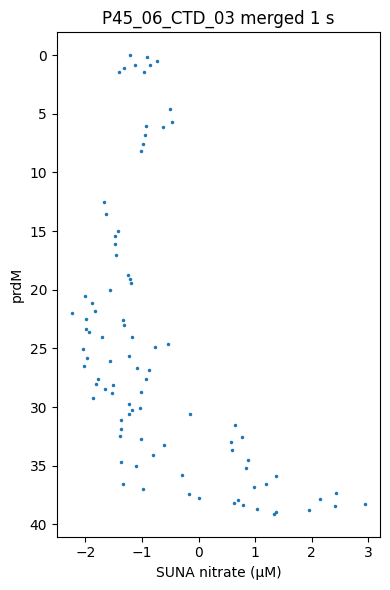

In [9]:
def quick_check(cast_id: str) -> None:
    f = L2_SUNA_ROOT / f"{cast_id}_SUNA_1s.csv"
    if not f.exists():
        print(f"No merged file for {cast_id}")
        return
    df = pd.read_csv(f)
    depth_col = next((c for c in df.columns if re.search(r"depS|depth|prDM|pressure", c, re.I)), None)
    frac = df["suna_nitrate"].notna().mean() if "suna_nitrate" in df else float("nan")
    print(f"{cast_id}: {len(df)} scans, SUNA coverage {frac:.1%}, depth col = {depth_col}")
    try:
        import matplotlib.pyplot as plt
        if depth_col and "suna_nitrate" in df:
            fig, ax = plt.subplots(figsize=(4, 6))
            ax.plot(df["suna_nitrate"], df[depth_col], ".", ms=3)
            ax.invert_yaxis()
            ax.set_xlabel("SUNA nitrate (\u00b5M)"); ax.set_ylabel(depth_col)
            ax.set_title(f"{cast_id} merged 1 s")
            plt.tight_layout(); plt.show()
    except Exception as exc:
        print(f"(plot skipped: {exc!r})")

if pairs:
    quick_check(pairs[0][0].name[:-len(CTD_1S_SUFFIX)])
